In [18]:
using Oceananigans
using CairoMakie
using CairoMakie.Colors

include("../src-fig/figures/preinitial_conditions.jl")
include("../src-simulation/parameters.jl")
include("../src-simulation/base_state.jl")
include("../src-simulation/grid_faces.jl")

get_grid_faces (generic function with 1 method)

The preinitial condition of the simulation is a tilted front above a thermocline, with a jet in thermal wind balance
$$
b_0(x, z) = \Delta bf\left (\frac{x}{\ell} + \frac{z+H/2}{H}\right )g'\left(\frac{z + H}{\lambda H}\right) + b_\infty(z),
\quad
v_0(x, z) = \int_{-\infty}^{z} b_0(x, z)\,\text{d}z \approx  \frac{H\Delta b}{\ell f}\left [f\left (\frac{x}{\ell} + \frac{z+H/2}{H}\right )-f\left (\frac{x}{\ell} - \frac{1}{2}\right )\right ]
$$
with
$$
f(s) = \frac{1}{2}\big(1 + \tanh(s)\big), \quad g(s) = \ln (1 + e^s), \quad \text{and} \quad b_\infty(z) = -\lambda HN^2_0g\left(-\frac{z + H}{\lambda H}\right)
$$
where $\Delta b$ is the frontal buoyancy change, $\ell$ is the frontal half-width, $H$ is the mixed-layer depth, $N_0$ is the thermocline buoyancy frequency and $\lambda$ is the thermocline transition width. At the surface, the velocity and vorticity are approximately
$$
v \approx \frac{H\Delta b}{\ell f}f'\left (\frac{x}{\ell}\right ) \quad \text{and} \quad \zeta \approx \frac{H\Delta b}{\ell^2 f}f''\left (\frac{x}{\ell}\right )
$$

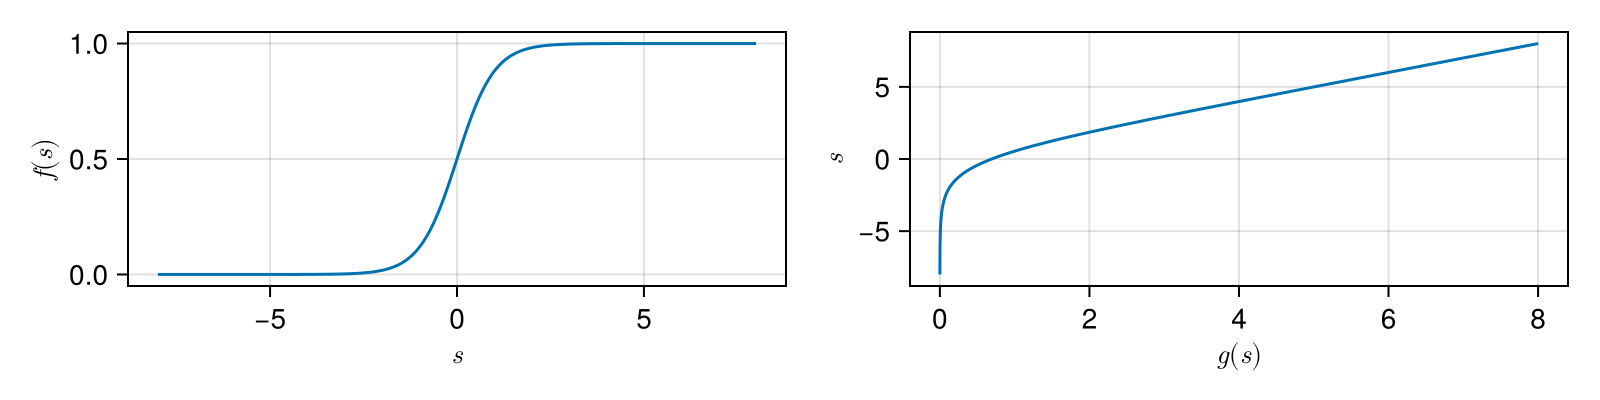

In [3]:
fig = Figure(; size = (800, 200))
s = range(-8, 8, 256)

ax = Axis(fig[1, 1];
    xlabel = L"s",
    ylabel = L"f(s)"
)
lines!(ax, s, f)

ax = Axis(fig[1, 2];
    xlabel = L"g(s)",
    ylabel = L"s"
)
lines!(ax, g.(s), s)

fig

Simulation input parameters start with defining length, height and time scales via the mixed layer deformation radius $L_D$, mixed layer depth $H = \beta_H L_D$ and the Coriolis frequency $f$. This immediately specifies the front with $\text{Ri}_\text{min}=1$, which has buoyancy change $\Delta b_D$ and width $L_D$. Within the front, 
$$
N^2 = \frac{\Delta b}{H}f'\left (\frac{x}{\ell} + \frac{z+H/2}{H}\right ) \quad S = \frac{\Delta b}{\ell f}f'\left (\frac{x}{\ell} + \frac{z+H/2}{H}\right ) 
$$
$$
Ri = \frac{N^2}{S^2} = \frac{\ell^2 f^2}{H\Delta b}\frac{1}{f'\left (\frac{x}{\ell} + \frac{z+H/2}{H}\right )} \implies \text{Ri}_\text{min} = 2\frac{\ell^2 f^2}{H\Delta b}
$$
$$
\implies \Delta b_D = 2\frac{L_D^2 f^2}{H}
$$
The thermocline stratification is chosen to have a deformation radius $\beta_0 =8$ times greater than mixed layer

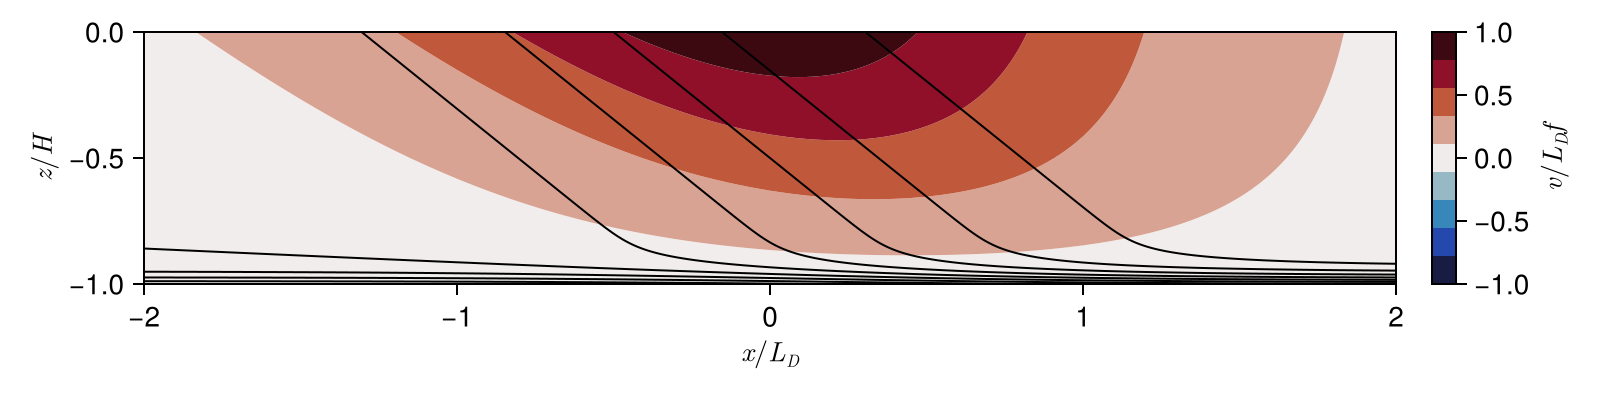

In [4]:
ip = (; f=1, L=1, βb=1, βℓ=1, βH=1, β₀=8)
sp = create_simulation_parameters(ip)

fig = Figure(; size = (800, 200))
xs = range(-2sp.L, 2sp.L, 256)
zs = range(-sp.H, 0, 256)

bD = [front_buoyancy(x, z, sp) for x in xs, z in zs]
vD = [approximate_front_velocity(x, z, sp) for x in xs, z in zs]

ax = Axis(fig[1, 1];
    xlabel = L"x / L_D",
    ylabel = L"z / H",
    limits = (-2sp.L, 2sp.L, -sp.H, 0)
)


ctf = contourf!(ax, xs, zs, vD; 
    colormap = :balance, 
    levels = range(-1, 1, 10)
)

contour!(ax, xs, zs, bD; 
    levels = -10sp.Δb:(sp.Δb/6):sp.Δb, 
    color = :black
)
Colorbar(fig[1, 2], ctf; label=L"v / L_D f")

fig

Fronts are parametrised relative to this reference state with ratios $\beta_b$ and $\beta_\ell$.
$$
\Delta b = \beta_b \Delta b_D\quad \ell = \beta_\ell L_D,  \quad \text{Ri}_\text{min} = \frac{\beta_\ell^2}{\beta_b}, \quad v_\text{max} = \frac{\beta_b}{\beta_\ell}L_D f, \quad \text{Ro}_\text{max} \approx 0.7698\frac{\beta_b}{\beta_\ell^2}
$$
The simulation domain is, also,
$$
L_x = \beta_x L_D, \quad L_h = \beta_h L_D, \quad L_z = 1.5H.
$$
Grid sizes $N_x, N_h, N_y, N_z$ are input, with $L_y = N_y L_h / N_h$. The grid has a variable spacing in the x direction, with a central, high-resolution region and two outer regions with quadratically expanding across-front grid size. For a grid with face indices $[-N_x/2, N_x/2]$, cell faces are at
$$
x_\text{faces}(n) = \frac{L_h}{N_h}n + \frac{L_x - \frac{N_x}{N_h}L_h}{4(N_x - N_h)^3} \times \left \{ \begin{array}{ll}
(n + \frac{N_h}{2})^3 & -\frac{N_x}{2} \leq n \leq -\frac{N_h}{2}\\
0 & -\frac{N_h}{2} \leq n \leq \frac{N_h}{2} \\
(n - \frac{N_h}{2})^3 & \frac{N_h}{2} \leq n \leq \frac{N_x}{2}
\end{array}\right .
$$
Finally, the surface buoyancy flux $B$ and background strain rate $\alpha$ are determined by specifying the turbulent Ekman number $\text{Ek} = \frac{1}{f\tau}$ where $\tau = (H^2 / B)^{1/3}$ is the mixing timescale and the deformation Rossby number $\text{Ro}_\alpha = \alpha / f$
$$
B = H^2 / \tau^3 = \text{Ek}^3 H^2 f^3 \quad \alpha = \text{Ro}_\alpha f
$$

# Simulation set
We run dimensional simulations based on typical sizes of the Coriolis frequency and mixed layer deformation radius.
$$
f = 10^{-4}~\text{s}^{-1}\quad L_D = 1~\text{km}
$$

The simulation domain parameters
$$
(N_x, N_y, N_z) = (1024, 128, 64), \quad N_h = 768, \quad \beta_x = 32, \quad \beta_h = 4
$$
The front buoyancy change, aspect ratio and thermocline deformation radius are constant
$$
\beta_b = 1, \quad \beta_H = 0.1, \quad \beta_0 = 8
$$
## Initial width
We first run some simulations to determine an appropriate initial width for the front.
$$
\beta_\ell \in \{2, 4, 6, 8\}, \quad \text{Ro}_\alpha = 0.1, \quad \text{Ek} = 1.7
$$

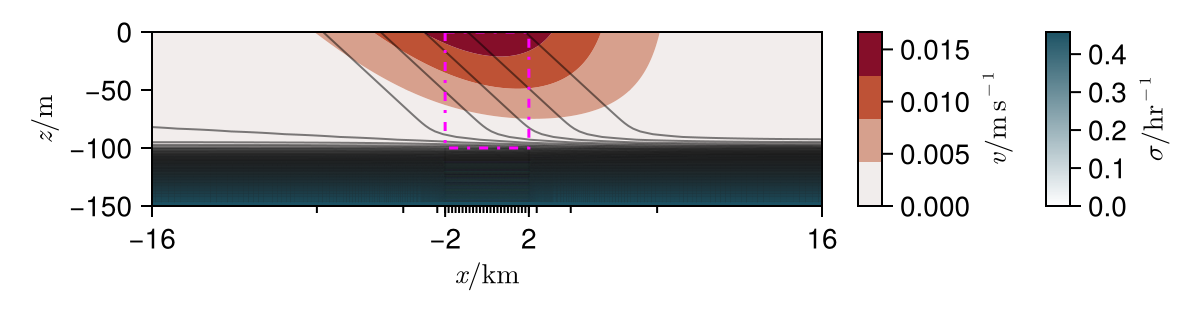

In [26]:
ip = (;
    run_time = 8e5, start_time = -4e5, save_time = 1e3,
    f = 1e-4, L = 1e3,
    βx = 32, βh = 4,
    Nx = 1024, Nh = 768, Ny = 128, Nz = 64,
    βb = 1, βℓ = 6, βH = 0.1,
    Roα = 0.1, Ek = 1.7, β₀ = 8
)

sp = create_simulation_parameters(ip)
preinitial_conditions(sp)

Based on the results of the above, we choose
$$
\beta_\ell = 6, \quad \beta_x = 20, \quad \beta_h = 3
$$
and
$$
(N_x, N_y, N_z) = (1024, 128, 128), \quad N_h = 768
$$
for the later simulations. This gives a central region resolution of
$$
\Delta x = \Delta y = 3.9\text{m}\quad \Delta z = 1.17\text{m}
$$

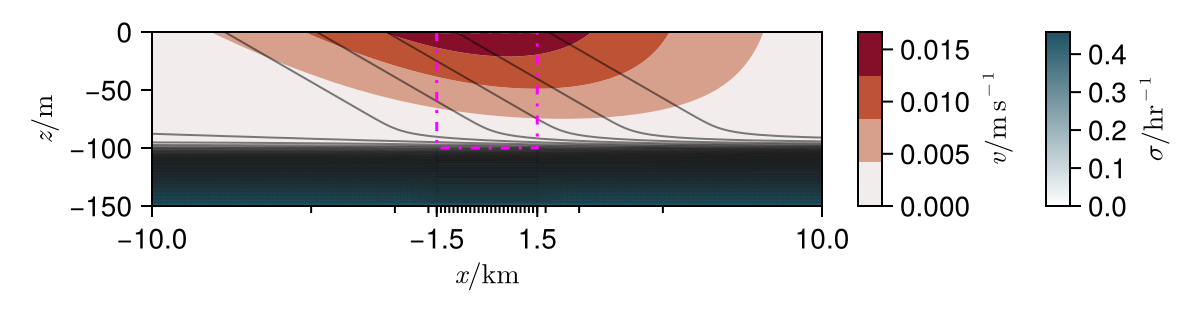

In [47]:
ip = (;
    run_time = 16e5, start_time = -4e5, save_time = 1e3,
    f = 1e-4, L = 1e3,
    βx = 20, βh = 3,
    Nx = 1024, Nh = 768, Ny = 128, Nz = 128,
    βb = 1, βℓ = 6, βH = 0.1,
    Roα = 0.1, Ek = 1.7, β₀ = 8
)

sp = create_simulation_parameters(ip)
preinitial_conditions(sp)

We run the above simulation for varying values of the cooling and strain rate
$$
\text{Ro}_\alpha \in\{ 0.03, 0.1, 0.3\}\quad \text{Ek} \in \{0, 0.7, 1, 1.4, 2\}
$$
With cooling, pre-initialisation is performed for $80\tau$. Simulations are run until $\alpha t = 10$. First, we run the set with $\text{Ro}_\alpha = 0.1$. The simulation state is saved every $1/f$ during pre-initialisation and $0.1/f$ after the strain turns on. Later post-processing for down-front means, slices, and other fields. The same initialised state is used for the different values of the strain.

In [50]:
for Ek in [0.7, 1.0, 1.4, 2.0]
    ip = (;
        run_time = 16e5, start_time = -4e5, save_time = 1e3,
        f = 1e-4, L = 1e3,
        βx = 20, βh = 3,
        Nx = 1024, Nh = 768, Ny = 128, Nz = 128,
        βb = 1, βℓ = 6, βH = 0.1,
        Roα = 0.1, Ek, β₀ = 8
    )
    sp = create_simulation_parameters(ip)
    println(80sp.τ / 1e5)
end

11.428571428571429
8.0
5.714285714285714
4.0
